# Define Data Points to use - Step 1

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
x = np.array([0, 1, 2, 3, 4, 5], dtype='float')
y = np.array([0, 2, 0, 3, 0, 2], dtype='float')

# Set up and Solve Tridiagonal System - Steps 2 and 3

In [43]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step 2: Calculates the step sizes in between each x value
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])    # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i]) / h[i] - (y[i]-y[i-1])/h[i-1])             # Right-hand side vector
    return A, B, C, D
# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

# Thomas Algorithm - Step 3

In [44]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

M_inner = thomas_algorithm(A, B, C, D)
M = np.concatenate(([0], M_inner, [0])) #Natural boundary conditions are added to ensure M1 = Mn = 0

# Evaluate Spline

In [47]:
def evaluate_spline(x_data, y_data, M, x_query):
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
    (M[i] / (6*hi)) * dx_right**3 + # Term 1
    (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
    (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
    (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

x_interp = np.linspace(0, 5, 100)
y_interp = evaluate_spline(x, y, M, x_interp)

# Plotting

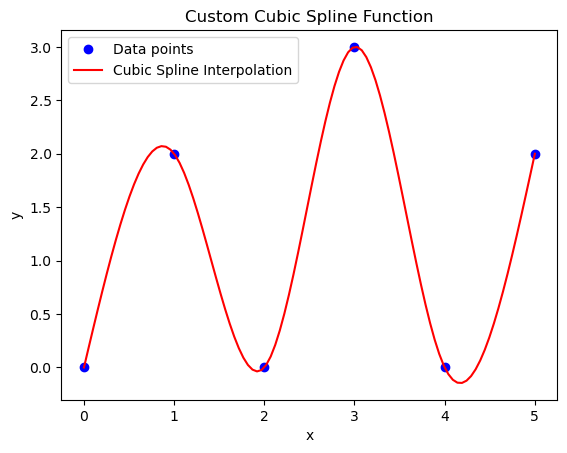

In [49]:
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_interp, y_interp, 'r-', label="Cubic Spline Interpolation")
plt.title("Custom Cubic Spline Function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# I used Gemini Pro on this assignment to double check that my work is correct and returns something valid.